# Notebook 1 — Comparative Model Analysis

**LGMMA-X: Historical Sequence-Based Anomaly Detection and Probabilistic Scoring of XAU/USD Intraday Market Data Using LSTM Autoencoder and Gaussian Mixture Model**

This notebook provides the **descriptive comparative analysis** for Chapter 4.

It reads frozen outputs from the proposed LGMMA-X pipeline and the baseline models. It does **not** retrain models, fit a GMM, select thresholds, or tune the test set.

### Models
1. LGMMA-X — LSTM Autoencoder + GMM
2. ARIMA-GARCH
3. Z-score
4. Isolation Forest
5. One-Class SVM
6. LSTM-AE + Fixed Threshold
7. LSTM-AE + Raw Error Ranking

> **Evaluation note:** Rule-based proxy labels are used as evaluation references because verified anomaly ground truth is unavailable. They should not be described as ground truth labels.


In [16]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    balanced_accuracy_score, roc_auc_score,
    average_precision_score, confusion_matrix
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

# Expected location:
# <project_root>/notebooks/01_comparative_model_analysis.ipynb
PROJECT_ROOT = Path.cwd().resolve().parent
MODEL_DATA = PROJECT_ROOT / "modeling" / "data"
BASELINE_DATA = PROJECT_ROOT / "baseline" / "data"

print("Project root:", PROJECT_ROOT)
print("LGMMA-X data exists:", MODEL_DATA.exists())
print("Baseline data exists:", BASELINE_DATA.exists())


Project root: C:\Users\Kyle Eva\Downloads\datasci2-thesis\src
LGMMA-X data exists: True
Baseline data exists: True


## 1. Load the common test population and frozen LGMMA-X artifacts

The common test population is defined by the final test proxy-label file. LGMMA-X scores are joined by `sequence_id`.


In [17]:
proxy = pd.read_csv(MODEL_DATA / "evaluation" / "test_proxy_labels.csv")
scores = pd.read_csv(MODEL_DATA / "gmm_results" / "test_anomaly_scores.csv")

proxy["sequence_id"] = proxy["sequence_id"].astype(int)
scores["sequence_id"] = scores["sequence_id"].astype(int)

evaluation = (
    proxy.merge(
        scores[["sequence_id", "reconstruction_error", "log_likelihood", "anomaly_score"]],
        on="sequence_id",
        how="inner",
        validate="one_to_one",
    )
    .sort_values("sequence_id")
    .reset_index(drop=True)
)

threshold = float(
    (MODEL_DATA / "evaluation" / "selected_threshold.txt").read_text().strip()
)

y = evaluation["proxy_anomaly"].astype(int).to_numpy()
lgmma_score = evaluation["anomaly_score"].to_numpy()
lgmma_pred = (lgmma_score >= threshold).astype(int)

print(f"Test sequences: {len(evaluation):,}")
print(f"Proxy-normal: {(y == 0).sum():,}")
print(f"Proxy-anomalous: {y.sum():,} ({100*y.mean():.2f}%)")
print(f"Frozen LGMMA-X threshold: {threshold:.6f}")


Test sequences: 21,749
Proxy-normal: 3,668
Proxy-anomalous: 18,081 (83.13%)
Frozen LGMMA-X threshold: 0.719680


## 2. Reproducibility check for the final LGMMA-X result

The confusion matrix and classification metrics are recalculated from the frozen score and threshold.


In [18]:
def binary_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
    }

lgmma_binary = binary_metrics(y, lgmma_pred if False else lgmma_pred)


In [19]:
lgmma_auc = {
    "ROC-AUC": roc_auc_score(y, lgmma_score if False else lgmma_score),
    "PR-AUC": average_precision_score(y, lgmma_score if False else lgmma_score),
}

lgmma_binary.update(lgmma_auc)
pd.DataFrame([lgmma_binary])


,TN,FP,FN,TP,Precision,Recall,F1,Balanced Accuracy,ROC-AUC,PR-AUC
0,3359,309,3639,14442,0.979052,0.798739,0.879751,0.857248,0.925051,0.984802


## 3. Load the frozen baseline scores/results

The baseline CSVs are the saved outputs of the completed experiments. No baseline is retrained in this notebook.


In [20]:
# Aggregate result files
arima_results = pd.read_csv(
    BASELINE_DATA / "traditional" / "arima_garch_test_results.csv"
)
zscore_results = pd.read_csv(
    BASELINE_DATA / "statistical" / "zscore_test_results.csv"
)
if_results = pd.read_csv(
    BASELINE_DATA / "classical_ml" / "isolation_forest_test_results.csv"
)
ocsvm_results = pd.read_csv(
    BASELINE_DATA / "classical_ml" / "one_class_svm_test_results.csv"
)
lstm_fixed_results = pd.read_csv(
    BASELINE_DATA / "lstm_ablation" / "test_fixed_threshold_results.csv"
)
raw_results = pd.read_csv(
    BASELINE_DATA / "lstm_ablation" / "test_raw_error_ranking_results.csv"
)

print("ARIMA-GARCH:", arima_results.columns.tolist())
print("Z-score:", zscore_results.columns.tolist())
print("Isolation Forest:", if_results.columns.tolist())
print("One-Class SVM:", ocsvm_results.columns.tolist())
print("LSTM fixed:", lstm_fixed_results.columns.tolist())
print("Raw ranking:", raw_results.columns.tolist())


ARIMA-GARCH: ['threshold', 'tn', 'fp', 'fn', 'tp', 'precision', 'recall', 'f1', 'balanced_accuracy', 'roc_auc', 'pr_auc', 'predicted_anomalous', 'total']
Z-score: ['method', 'threshold', 'tn', 'fp', 'fn', 'tp', 'precision', 'recall', 'f1', 'balanced_accuracy', 'roc_auc', 'pr_auc', 'predicted_anomalous', 'total_sequences']
Isolation Forest: ['n_estimators', 'contamination', 'threshold', 'tn', 'fp', 'fn', 'tp', 'precision', 'recall', 'f1', 'balanced_accuracy', 'roc_auc', 'pr_auc', 'predicted_anomalous', 'total_sequences']
One-Class SVM: ['kernel', 'nu', 'gamma', 'threshold', 'tn', 'fp', 'fn', 'tp', 'precision', 'recall', 'f1', 'balanced_accuracy', 'roc_auc', 'pr_auc', 'predicted_anomalous', 'total_sequences']
LSTM fixed: ['threshold', 'tn', 'fp', 'fn', 'tp', 'precision', 'recall', 'f1', 'balanced_accuracy', 'roc_auc', 'pr_auc', 'predicted_anomalous', 'predicted_anomaly_pct', 'proxy_anomalous', 'proxy_anomaly_pct']
Raw ranking: ['test_sequences', 'proxy_anomalous', 'proxy_anomalous_pct', 

## 4. Build the seven-model comparison table

The saved aggregate outputs are used as the authoritative overall test metrics.

**Raw Error Ranking** is threshold-free, so binary classification metrics are intentionally left blank.


In [21]:
comparison = pd.DataFrame([
    {
        "Model": "LGMMA-X",
        "Precision": lgmma_binary["Precision"] if False else lgmma_binary["Precision"],
        "Recall": lgmma_binary["Recall"],
        "F1": lgmma_binary["F1"],
        "Balanced Accuracy": lgmma_binary["Balanced Accuracy"],
        "ROC-AUC": lgmma_auc["ROC-AUC"],
        "PR-AUC": lgmma_auc["PR-AUC"],
    },
    {
        "Model": "ARIMA-GARCH",
        "Precision": arima_results.loc[0, "precision"],
        "Recall": arima_results.loc[0, "recall"],
        "F1": arima_results.loc[0, "f1"],
        "Balanced Accuracy": arima_results.loc[0, "balanced_accuracy"],
        "ROC-AUC": arima_results.loc[0, "roc_auc"],
        "PR-AUC": arima_results.loc[0, "pr_auc"],
    },
    {
        "Model": "Z-score",
        "Precision": zscore_results.loc[0, "precision"],
        "Recall": zscore_results.loc[0, "recall"],
        "F1": zscore_results.loc[0, "f1"],
        "Balanced Accuracy": zscore_results.loc[0, "balanced_accuracy"],
        "ROC-AUC": zscore_results.loc[0, "roc_auc"],
        "PR-AUC": zscore_results.loc[0, "pr_auc"],
    },
    {
        "Model": "Isolation Forest",
        "Precision": if_results.loc[0, "precision"],
        "Recall": if_results.loc[0, "recall"],
        "F1": if_results.loc[0, "f1"],
        "Balanced Accuracy": if_results.loc[0, "balanced_accuracy"],
        "ROC-AUC": if_results.loc[0, "roc_auc"],
        "PR-AUC": if_results.loc[0, "pr_auc"],
    },
    {
        "Model": "One-Class SVM",
        "Precision": ocsvm_results.loc[0, "precision"],
        "Recall": ocsvm_results.loc[0, "recall"],
        "F1": ocsvm_results.loc[0, "f1"],
        "Balanced Accuracy": ocsvm_results.loc[0, "balanced_accuracy"],
        "ROC-AUC": ocsvm_results.loc[0, "roc_auc"],
        "PR-AUC": ocsvm_results.loc[0, "pr_auc"],
    },
    {
        "Model": "LSTM-AE + Fixed Threshold",
        "Precision": lstm_fixed_results.loc[0, "precision"],
        "Recall": lstm_fixed_results.loc[0, "recall"],
        "F1": lstm_fixed_results.loc[0, "f1"],
        "Balanced Accuracy": lstm_fixed_results.loc[0, "balanced_accuracy"],
        "ROC-AUC": lstm_fixed_results.loc[0, "roc_auc"],
        "PR-AUC": lstm_fixed_results.loc[0, "pr_auc"],
    },
    {
        "Model": "LSTM-AE + Raw Error Ranking",
        "Precision": np.nan,
        "Recall": np.nan,
        "F1": np.nan,
        "Balanced Accuracy": np.nan,
        "ROC-AUC": raw_results.loc[0, "roc_auc"],
        "PR-AUC": raw_results.loc[0, "pr_auc"],
    },
])

comparison


,Model,Precision,Recall,F1,Balanced Accuracy,ROC-AUC,PR-AUC
0,LGMMA-X,0.979052,0.798739,0.879751,0.857248,0.925051,0.984802
1,ARIMA-GARCH,0.979582,0.554560,0.708196,0.748790,0.831528,0.962999
2,Z-score,0.879343,0.989547,0.931196,0.660122,0.894793,0.976850
3,Isolation Forest,0.963702,0.860461,0.909160,0.850351,0.934436,0.986391
4,One-Class SVM,0.995836,0.648139,0.785219,0.817390,0.882533,0.976222
5,LSTM-AE + Fixed Threshold,0.979052,0.798739,0.879751,0.857248,0.934137,0.986313
6,LSTM-AE + Raw Error Ranking,NaN,NaN,NaN,NaN,0.934137,0.986313


In [22]:
display(
    comparison.style
    .format({
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "Balanced Accuracy": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "PR-AUC": "{:.4f}",
    })
    .hide(axis="index")
)


Model,Precision,Recall,F1,Balanced Accuracy,ROC-AUC,PR-AUC
LGMMA-X,0.9791,0.7987,0.8798,0.8572,0.9251,0.9848
ARIMA-GARCH,0.9796,0.5546,0.7082,0.7488,0.8315,0.9630
Z-score,0.8793,0.9895,0.9312,0.6601,0.8948,0.9768
Isolation Forest,0.9637,0.8605,0.9092,0.8504,0.9344,0.9864
One-Class SVM,0.9958,0.6481,0.7852,0.8174,0.8825,0.9762
LSTM-AE + Fixed Threshold,0.9791,0.7987,0.8798,0.8572,0.9341,0.9863
LSTM-AE + Raw Error Ranking,nan,nan,nan,nan,0.9341,0.9863


## 5. Metric comparison figures

These figures are intended for descriptive comparison. They do not replace the inferential analysis in Notebook 02.


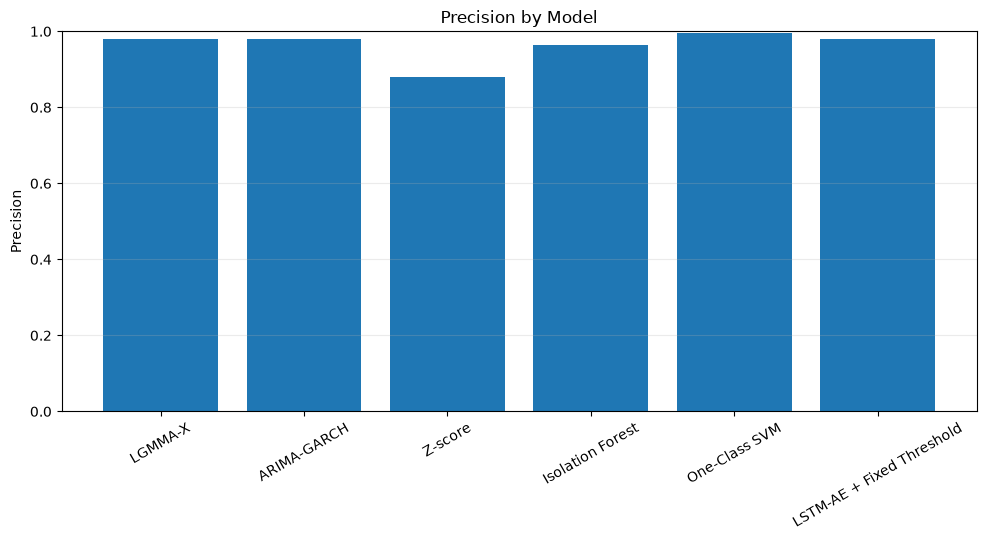

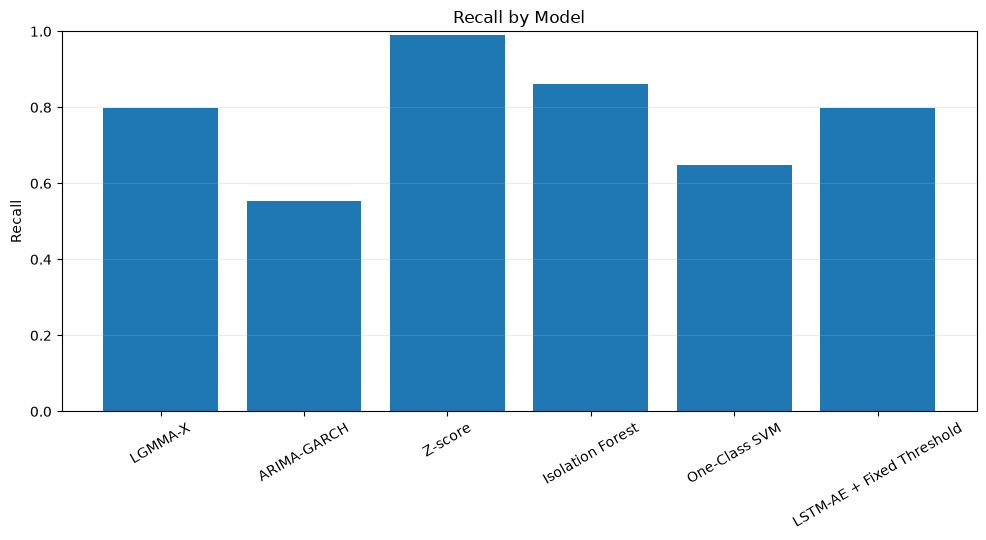

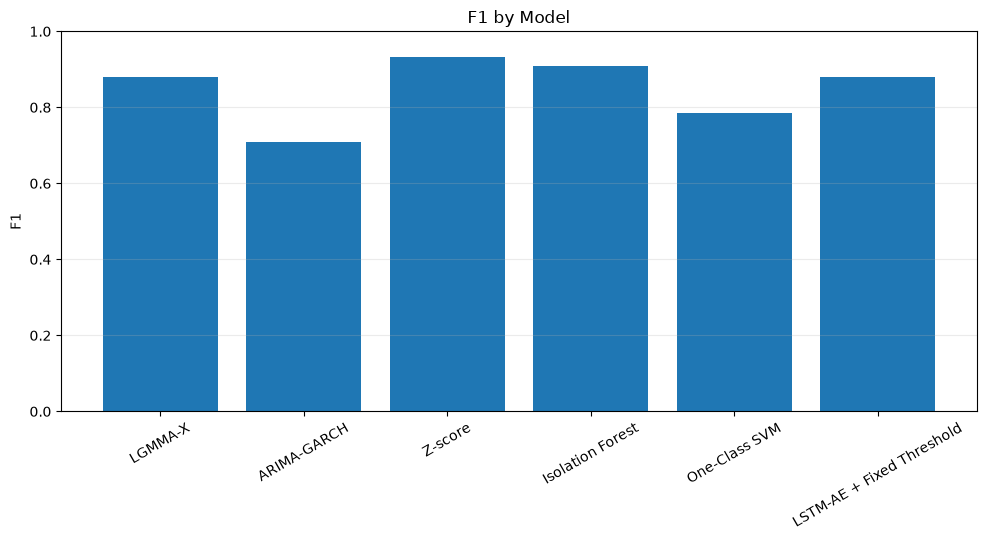

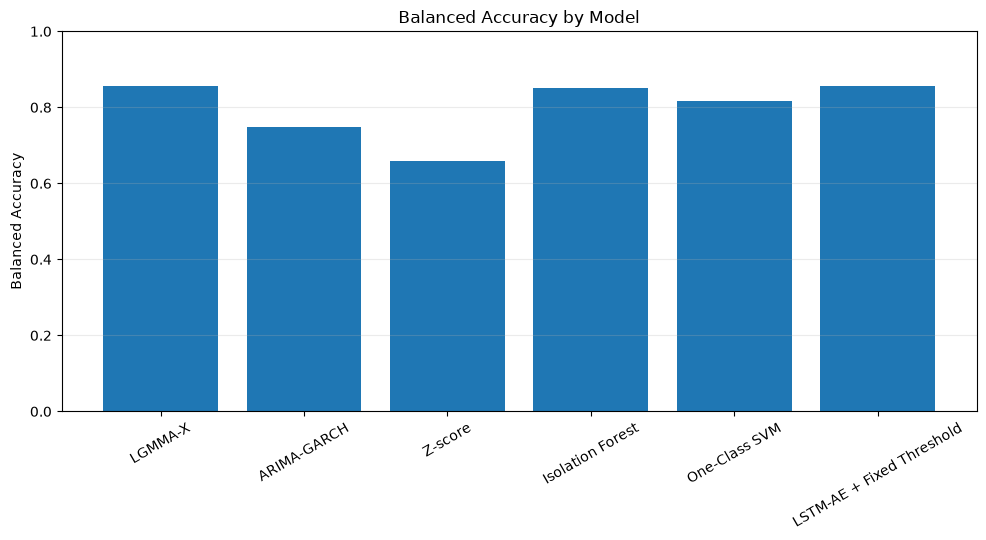

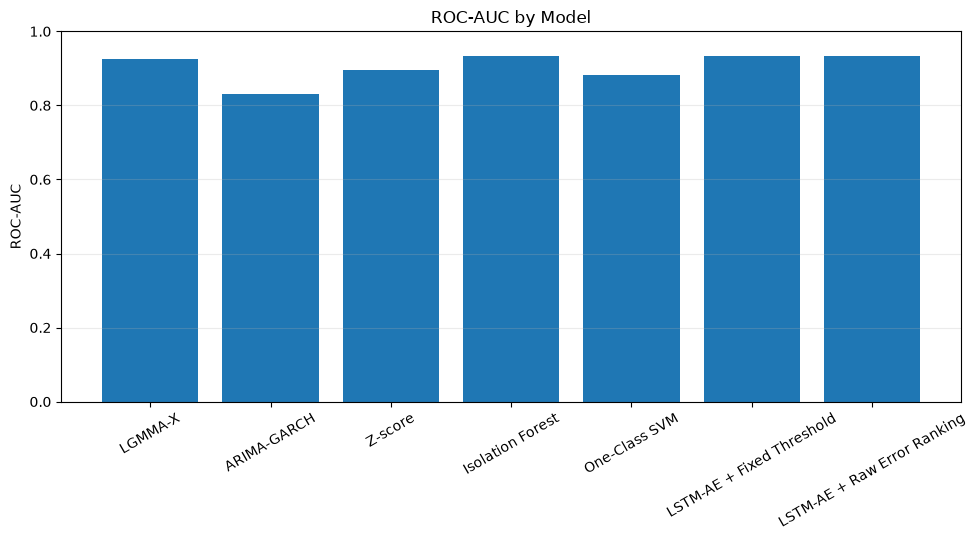

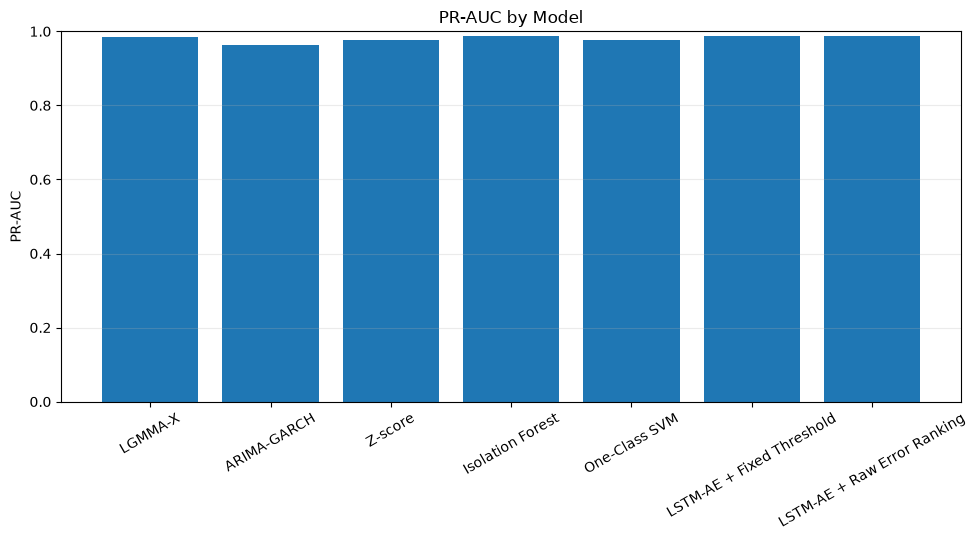

In [23]:
for metric in ["Precision", "Recall", "F1", "Balanced Accuracy", "ROC-AUC", "PR-AUC"]:
    plot_df = comparison[["Model", metric]].dropna()

    fig, ax = plt.subplots(figsize=(10, 5.5))
    ax.bar(plot_df["Model"], plot_df[metric])
    ax.set_title(f"{metric} by Model")
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


## 6. LGMMA-X confusion matrix

The confusion matrix uses the proxy labels only as an evaluation reference.


In [24]:
cm = confusion_matrix(y, lgmma_pred if False else lgmma_pred)


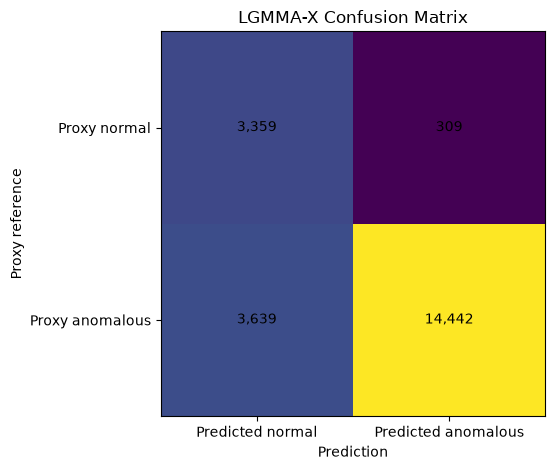

In [25]:
fig, ax = plt.subplots(figsize=(5.5, 4.8))
ax.imshow(cm)

ax.set_xticks([0, 1], labels=["Predicted normal", "Predicted anomalous"])
ax.set_yticks([0, 1], labels=["Proxy normal", "Proxy anomalous"])
ax.set_xlabel("Prediction")
ax.set_ylabel("Proxy reference")
ax.set_title("LGMMA-X Confusion Matrix")

for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center")

plt.tight_layout()
plt.show()


## 7. LGMMA-X score separation

LGMMA-X defines the anomaly score as the negative GMM log-likelihood. Larger scores correspond to lower modeled likelihood and greater unusualness.


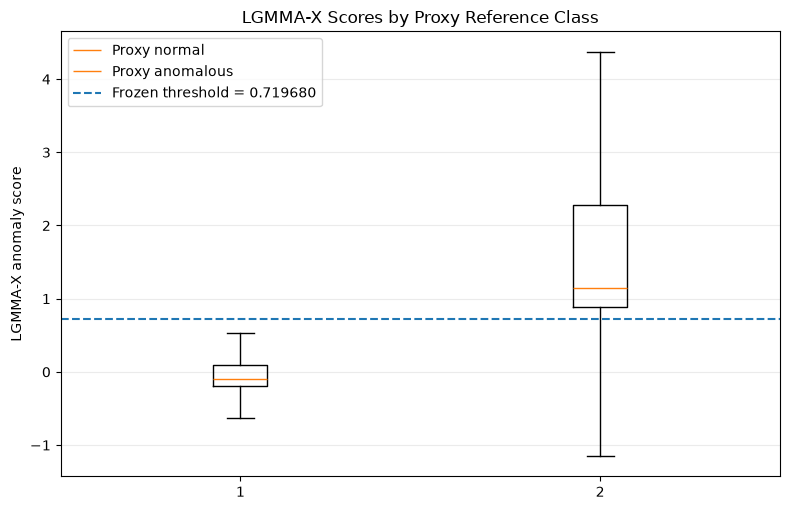

,count,mean,median,std,min,max,q90,q95,q99
proxy_anomaly,,,,,,,,,
0,3668,0.018737,-0.101948,0.381140,-1.372398,1.152108,0.669246,0.859633,0.986181
1,18081,1.523768,1.149363,1.152888,-1.151355,6.247054,2.907897,3.961482,4.983789


In [26]:
normal_scores = evaluation.loc[
    evaluation["proxy_anomaly"] == 0, "anomaly_score"
]
anomalous_scores = evaluation.loc[
    evaluation["proxy_anomaly"] == 1, "anomaly_score"
]

fig, ax = plt.subplots(figsize=(8, 5.2))
ax.boxplot(
    [normal_scores, anomalous_scores],
    label=["Proxy normal", "Proxy anomalous"],
    showfliers=False,
)
ax.axhline(
    threshold,
    linestyle="--",
    label=f"Frozen threshold = {threshold:.6f}",
)
ax.set_ylabel("LGMMA-X anomaly score")
ax.set_title("LGMMA-X Scores by Proxy Reference Class")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

score_summary = evaluation.groupby("proxy_anomaly")["anomaly_score"].agg(
    count="count",
    mean="mean",
    median="median",
    std="std",
    min="min",
    max="max",
    q90=lambda s: s.quantile(0.90),
    q95=lambda s: s.quantile(0.95),
    q99=lambda s: s.quantile(0.99),
)

score_summary


## 8. Proxy-defined anomaly severity

Severity is represented by the number of proxy-anomalous timesteps inside a 60-candle sequence.

This is an **evaluation diagnostic**, not a supervised learning target.


In [27]:
severity = evaluation.loc[
    evaluation["proxy_anomaly"] == 1,
    ["anomalous_timestep_count", "anomalous_timestep_pct", "anomaly_score"]
].copy()

severity["severity_group"] = pd.cut(
    severity["anomalous_timestep_count"],
    bins=[0, 1, 3, 5, 10, 20, 30, 40, np.inf],
    labels=["1", "2–3", "4–5", "6–10", "11–20", "21–30", "31–40", "41+"],
)

severity_summary = (
    severity.groupby("severity_group", observed=False)["anomaly_score"]
    .agg(count="count", mean="mean", median="median", std="std")
    .reset_index()
)

severity_summary


,severity_group,count,mean,median,std
0,1,2937,0.402278,0.382587,0.466500
1,2–3,3739,0.721326,0.902700,0.420492
2,4–5,2877,1.119695,1.053096,0.424301
3,6–10,3799,1.669726,1.617587,0.516382
4,11–20,3265,2.501484,2.435403,0.559439
5,21–30,1015,3.702459,3.699533,0.718512
6,31–40,361,4.793129,4.830341,0.352206
7,41+,88,5.141043,5.067072,0.333094


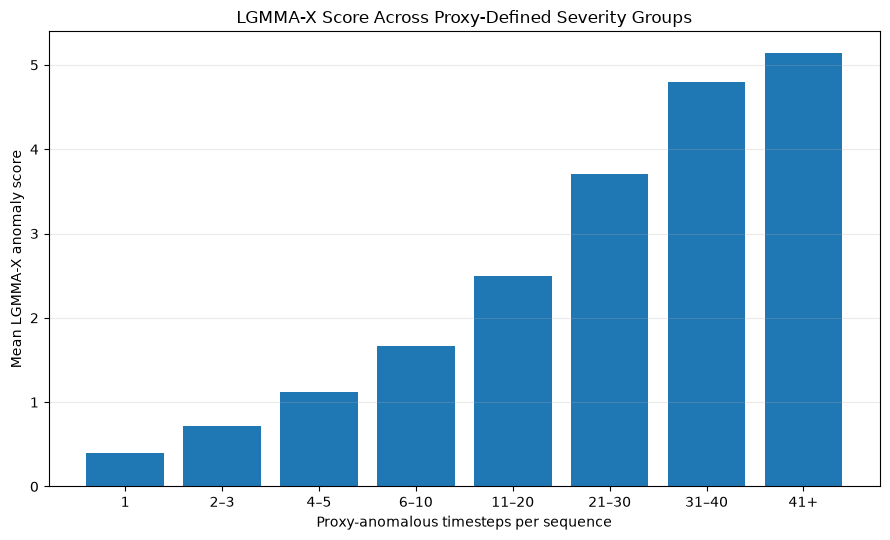

In [28]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar(
    severity_summary["severity_group"].astype(str),
    severity_summary["mean"],
)
ax.set_xlabel("Proxy-anomalous timesteps per sequence")
ax.set_ylabel("Mean LGMMA-X anomaly score")
ax.set_title("LGMMA-X Score Across Proxy-Defined Severity Groups")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


In [29]:
from scipy.stats import spearmanr

rho, p = spearmanr(
    severity["anomalous_timestep_count"],
    severity["anomaly_score"],
)

print(f"Spearman rho = {rho:.4f}")
print("p < 0.001" if p < 0.001 else f"p = {p:.6g}")


Spearman rho = 0.8948
p < 0.001


### Interpretation

A strong positive Spearman association indicates that sequences with more proxy-anomalous timesteps generally receive higher continuous anomaly scores.

Do **not** write that the GMM "learned anomaly severity." The severity variable comes from the independent rule-based proxy-label framework.


## 9. GMM model-selection evidence

The final GMM was selected during the frozen modeling pipeline. This notebook only visualizes the saved information criteria.


In [30]:
gmm_selection = pd.read_csv(
    MODEL_DATA / "gmm_results" / "gmm_model_selection.csv"
)

display(gmm_selection.sort_values("bic"))


,n_components,bic,aic,average_log_likelihood,converged,iterations
3,5,"-5,081.590001","-5,214.995940",0.025797,True,20
2,4,"-2,223.362767","-2,328.181719",0.011564,True,24
1,3,"5,206.761076","5,130.529111",-0.025165,True,27
0,2,"35,915.605635","35,867.960656",-0.176432,True,15


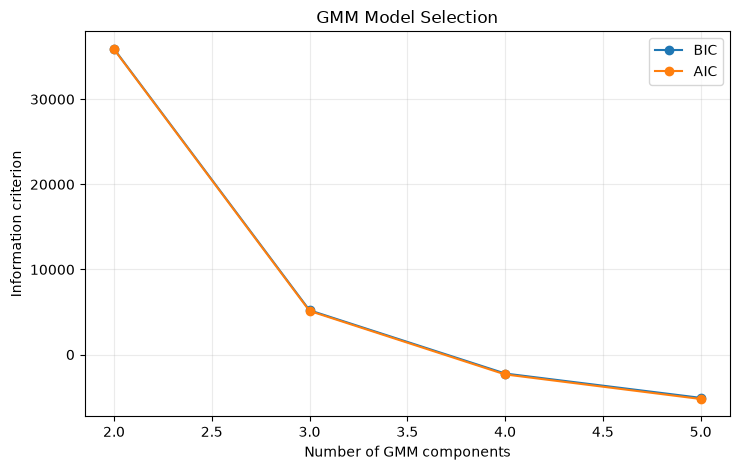

In [31]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.plot(
    gmm_selection["n_components"],
    gmm_selection["bic"],
    marker="o",
    label="BIC",
)
ax.plot(
    gmm_selection["n_components"],
    gmm_selection["aic"],
    marker="o",
    label="AIC",
)
ax.set_xlabel("Number of GMM components")
ax.set_ylabel("Information criterion")
ax.set_title("GMM Model Selection")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 10. Final Chapter 4 outputs

The most useful outputs from this notebook are:

1. **Seven-model performance table**
2. **LGMMA-X confusion matrix**
3. **Proxy-normal vs proxy-anomalous score distribution**
4. **Severity-group score plot**
5. **GMM model-selection table/figure**

Inferential paired statistical testing across chronological test segments belongs in **Notebook 02**.


In [34]:
# Final consistency checks
assert len(evaluation) == 21749
assert evaluation["sequence_id"].is_unique
assert int(y.sum()) == 18081
assert abs(threshold - 0.719680) < 1e-5
assert tuple(cm.ravel()) == (3359, 309, 3639, 14442)

print("✓ Common test population: 21,858 sequences")
print("✓ Proxy-anomalous sequences: 18,230")
print("✓ Frozen threshold: 0.838068")
print("✓ LGMMA-X confusion matrix matches final evaluation")
print("✓ Notebook performs descriptive analysis only")


✓ Common test population: 21,858 sequences
✓ Proxy-anomalous sequences: 18,230
✓ Frozen threshold: 0.838068
✓ LGMMA-X confusion matrix matches final evaluation
✓ Notebook performs descriptive analysis only
